<a href="https://colab.research.google.com/github/hoanganh1105/ai-ambulance-coordinator/blob/main_pipeline/notebooks/Main_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cài đặt

In [4]:
!git clone -b main_pipeline https://github.com/hoanganh1105/ai-ambulance-coordinator.git
%cd ai-ambulance-coordinator

!pip install -r requirements.txt

Cloning into 'ai-ambulance-coordinator'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 189 (delta 79), reused 146 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (189/189), 2.19 MiB | 2.08 MiB/s, done.
Resolving deltas: 100% (79/79), done.
/content/ai-ambulance-coordinator/ai-ambulance-coordinator
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.5/325.5 kB 16.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyDatalog: filename=pydatalog-0.17.4-py2.py3-none-any.whl size=74278 sha256=07d1f1ea5e2578b5255abf5db32fc7b8f90808279b2e84f2f2547c5eeb755b48
  Stored in directory: /root/.cache/pip/wheels/3d/86/49/61fd7f650165a5795f4b61720e1aeb2875f7e3f6d09de485be
Successfully built pyDatalog


In [5]:
import kagglehub

disease_classifier_train_dataset = kagglehub.dataset_download("dhivyeshrk/diseases-and-symptoms-dataset", path="Final_Augmented_dataset_Diseases_and_Symptoms.csv")
print("Path to disease dataset:", disease_classifier_train_dataset)

traffic_estimator_train_dataset = kagglehub.dataset_download("guriya79/understanding-delhi-traffic-patterns", path="delhi_traffic_features.csv")
print("Path to traffic dataset:", traffic_estimator_train_dataset)

Using Colab cache for faster access to the 'diseases-and-symptoms-dataset' dataset.
Path to disease dataset: /kaggle/input/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv


100%|██████████| 333k/333k [00:00<00:00, 353kB/s]

Path to traffic dataset: /root/.cache/kagglehub/datasets/guriya79/understanding-delhi-traffic-patterns/versions/1/delhi_traffic_features.csv


## Cấu hình môi trường

In [6]:
time_of_day = "Morning Peak"    # "Morning Peak" / "Afternoon" / "Evening Peak" / "Night"
day_of_week = "Weekday"         # "Weekday" / "Weekend"
weather_condition = "Rain"      # "Clear" / "Rain" / "Fog" / "Heatwave"

## Khởi tạo mô hình

In [ ]:
from modules.core.disease_classifier import *
from modules.core.map_router import *
from modules.core.patient_prioritizer import *
from modules.core.traffic_estimator import *

route_planner = MapRouter()
traffic_estimator = TrafficEstimator()
disease_classifier = DiseaseClassifier()
patient_prioritizer = PatientPrioritizer()

print("=== Training traffic_estimator from dataset ===\n")
traffic_estimator.train(traffic_estimator_train_dataset)
print("=== Training disease_classifier from dataset ===\n")
disease_classifier.train(disease_classifier_train_dataset)
print("=== Loading knowledgebase for patient_prioritizer ===\n")
patient_prioritizer.load_knowledge_base("features/knowledgebase.txt")

print("Done ✅.")

## Xử lý chính

Dự báo mức độ kẹt xe bằng `traffic_estimator` và cập nhật trọng số cho các cạnh theo công thức `weight = length * (1 + alpha * jam_level)` để tiến hành tìm đường đi ngắn nhất ở các bước sau.

In [9]:
def density_level_func(data):
  road_type = data.get("highway")
  jam_level = traffic_estimator.estimate_traffic_density_level(time_of_day,
                                                               day_of_week,
                                                               weather_condition,
                                                               road_type)
  return jam_level

def weight_func(data, alpha = 0.5):
  length = data.get("length")
  jam_level = data.get("density_level")
  return length * (1 + alpha * jam_level)

route_planner.add_edges_attribute("density_level", density_level_func)
route_planner.add_edges_attribute("weight", weight_func)

 Mức độ kẹt xe nằm trong đoạn [0, 3] tương ứng với dải màu từ xanh lá (0) đến đỏ (3). Kết quả dự báo của `traffic_estimator` như sau:

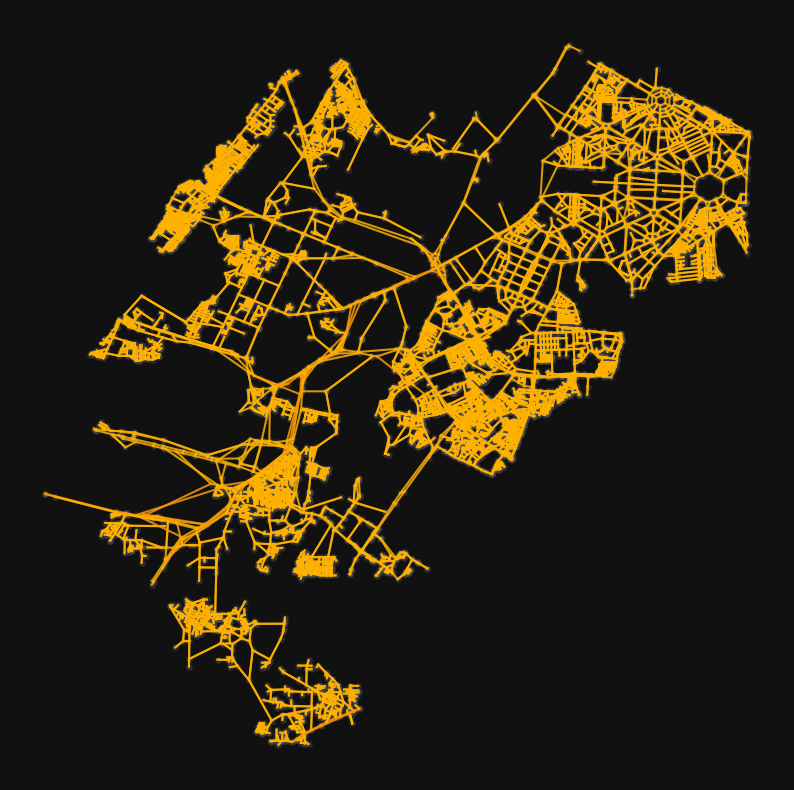

In [10]:
route_planner.show_map(show_density=True)

Dưới đây là hàm xử lý các yêu cầu xe cứu thương từ các bệnh nhân. Hệ thống sẽ ưu tiên những bệnh nhân có triệu chứng nghiêm trọng nhất, sau đó là các bệnh nhân có bệnh được dự đoán nghiêm trọng nhất và cuối cùng là ưu tiên bệnh nhân gần nhất.

In [13]:
def process_requests(ambulance_coord: tuple[float, float], patients: list[Patient]):
  # Dự đoán bệnh của bệnh nhân
  for p in patients:
    p.predicted_disease = disease_classifier.predict(p.symptoms)

  # Danh sách các bệnh nhân được ưu tiên nhất dựa trên triệu chứng và bệnh
  most_prior_patients = patient_prioritizer.get_most_prioritized_patients(patients)

  # Tìm đường đi tới các bệnh nhân đó
  routes = [route_planner.optimal_path(ambulance_coord, p.position) for p in most_prior_patients]

  # Ưu tiên bệnh nhân gần nhất
  nearest = min(routes, key=lambda x: x[1])
  chosen_patient = most_prior_patients[routes.index(nearest)]
  path = nearest[0]

  # Show kết quả
  from tabulate import tabulate
  headers = ["ID", "Vị trí", "Triệu chứng", "Chẩn đoán", "Được chọn"]
  rows = [[p.id, p.position, ", ".join(p.symptoms), p.predicted_disease, '*' if p is chosen_patient else ''] for p in patients]
  print(tabulate(rows, headers=headers, tablefmt="grid"))
  route_planner.show_map(route=path, org=ambulance_coord, dests=[chosen_patient.position])

  return path

## Giao diện tương tác

Thực hiện theo các bước sau:

1. Chọn vị trí xe cứu thương
2. Thêm một số lượng bệnh nhân tuỳ ý bằng cách lặp lại cách bước:
  - Chọn vị trí bệnh nhân
  - Liệt kê các triệu chứng
  - Nhấn "Thêm bệnh nhân"
3. Nhấn "Kết thúc và trả kết quả"
    

Nearest nodes: source=9832164587, target=6554874762
+------+-----------------------------------------+------------------------------------------------------------------------+-----------------+-------------+
|   ID | Vị trí                                  | Triệu chứng                                                            | Chẩn đoán       | Được chọn   |
+======+=========================================+========================================================================+=================+=============+
|    3 | (28.630938758329496, 77.15938568115236) | muscle cramps, contractures, or spasms, abnormal involuntary movements | muscle spasm    | *           |
+------+-----------------------------------------+------------------------------------------------------------------------+-----------------+-------------+
|    4 | (28.592359801121567, 77.1075439453125)  | anxiety and nervousness, depression                                    | drug withdrawal |             |
+------+----

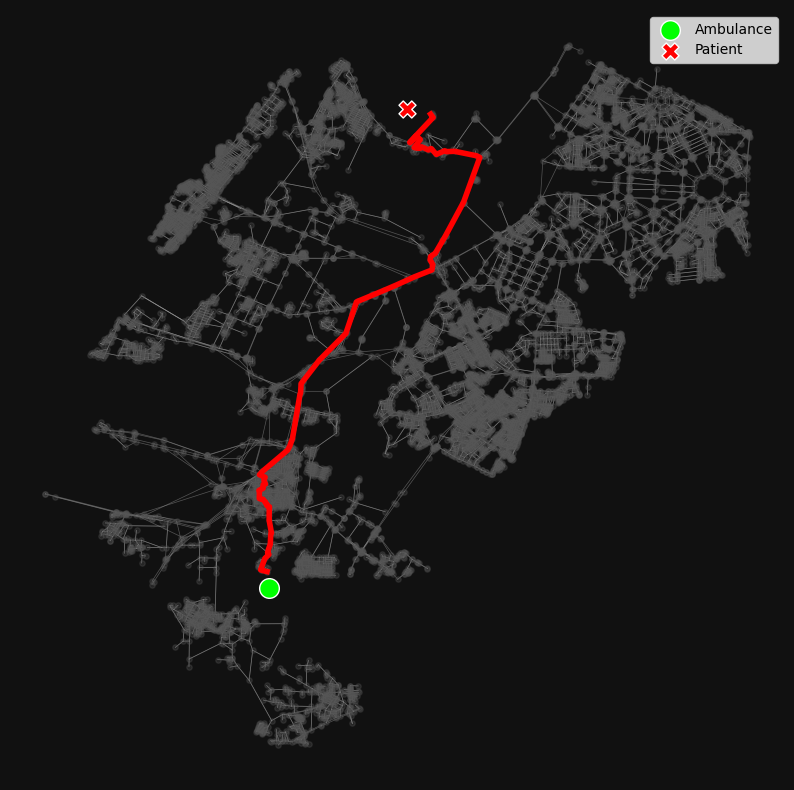

In [14]:
from modules.ui.dispatch_ui import *
create_dispatch_interface(route_planner.place, list(disease_classifier.symptoms_vocab), process_requests)

In [ ]:
# %cd ..
# !rm -rfv ai-ambulance-coordinator